![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 02 | Processing and Database Design

*Project 1 — SQL: From Data to Insight*

**Student:** Gabriel Gomes

**Dataset:** Inside Airbnb (Rio de Janeiro)

---

# Setup

In [ ]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import sqlite3
from pathlib import Path

%load_ext autoreload
%autoreload 2
from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
listings_raw = pd.read_csv("../data/raw/listings.csv.gz")
reviews_raw = pd.read_csv("../data/raw/reviews.csv.gz")
neighborhoods_raw = pd.read_csv("../data/raw/neighbourhoods.csv")
neighborhoods_geo_raw = gpd.read_file("../data/raw/neighbourhoods.geojson")
bairros = pd.read_csv("../data/raw/bairros.csv")

# 1. Data Cleaning

Work through the problems you listed in notebook 01. Every decision you make here — drop the nulls or keep them, cast or discard — is one you may be asked to defend on Friday, so note why.

## Column drop

The Inside Airbnb listings file has 90 columns, and a large share of them will not be useful for this analysis, for several different reasons. Each will be described below as the DataFrame is cleaned.

First, following the quality check performed in notebook 01, the columns whose values are all null are dropped, since they hold no information.
</br>

In [140]:
listings_clean = drop_null_columns(listings_raw)

The listings DataFrame column number is now reduced to 76.

In [141]:
len(listings_clean.columns)

76

Next, columns whose information has no analytical value for the project at hand are dropped. These are of the following kind:

- Scraping metadata: `scrape_id`, `last_scraped`, `source`, `calendar_last_scraped`.
- Media and redundant URLs: `picture_url`, `host_picture_url`, `host_profile_url`
- Redundancy: `host_profile_id`, `price_quote_total_price`, `price_quote_price_per_night`, `bathrooms`, `number_of_reviews_ltm`, `number_of_reviews_l30d`
- Irrelevant to the research questions: `hosts_time_as_user_years`, `hosts_time_as_user_months`, `host_location`, `host_about`, `latitude`, `host_identity_verified`,`host_has_profile_pic`, `longitude`, `price_quote_raw`, `price_quote_checkin_date`, `price_quote_checkout_date`, `minimum_minimum_nights`, `maximum_minimum_nights`, `minimum_maximum_nights`, `maximum_maximum_nights`, `minimum_nights_avg_ntm`, `maximum_nights_avg_ntm`, `availability_30`, `availability_60`, `availability_90`, `availability_365`, `availability_eoy`, `calculated_host_listings_count`, `calculated_host_listings_count_entire_homes`, `calculated_host_listings_count_private_rooms`, `calculated_host_listings_count_shared_rooms`, `estimated_revenue_l365d`, `number_of_reviews_ly`


In [142]:
irrelevant_columns = ['scrape_id', 'last_scraped', 'source', 'calendar_last_scraped','hosts_time_as_user_years', 'hosts_time_as_user_months', 'host_profile_id', 'host_profile_url', 'host_picture_url', 'picture_url', 'host_location', 'host_about', 'latitude', 'longitude', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'availability_eoy', 'host_identity_verified','host_has_profile_pic', 'price_quote_price_per_night', 'bathrooms', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'price_quote_raw', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'estimated_revenue_l365d','number_of_reviews_ly']

listings_clean = listings_clean.drop(columns=irrelevant_columns)

print(f'The column number is now reduced to {len(listings_clean.columns)}.')

The column number is now reduced to 35.


## Type Conversion

Now it's time to convert the inadequate data types identified earlier to the correct ones, so they can be properly handled during data processing. As noted in notebook 01, these include strings that should be booleans (`host_is_superhost`), strings that should be floats (`price`), and integers that should be floats (`minimum_nights`).

In [143]:
listings_clean["host_is_superhost"] = (
    listings_clean["host_is_superhost"]
    .str.strip()
    .str.lower()
    .map({"t": True, "f": False})
    .astype("boolean")
)

listings_clean["has_availability"] = (
    listings_clean["has_availability"]
    .str.strip()
    .str.lower()
    .map({"t": True, "f": False})
    .astype("boolean")
)

In [144]:
for column in ['host_listings_count', 'minimum_nights', 'maximum_nights', 'bedrooms', 'beds']:
    listings_clean[column] = listings_clean[column].astype("Int64")

Before type conversion, the '$' and ',' characters must also be removed from the `price` entries.

In [145]:
listings_clean["price"] = pd.to_numeric(
    listings_clean["price"].astype("string").str.replace("$", "", regex=False).str.replace(",", "", regex=False).str.strip(),
    errors="raise"
)

In addition, to make the project more readable for a European audience, prices, which are reported in Brazilian reais by default, will be converted to euros.

In [146]:
listings_clean["price"] = brl_to_eur(listings_clean["price"])

## Missing Values

For the columns that will be actively used in our analysis, we need to decide how to handle missing or null values. In the case of `review_scores_*`, the nulls come from listings that have not yet received any reviews. It is reasonable to leave them as they are, so they don't interfere with average calculations and misrepresent the data.

In [147]:
get_quality(listings_clean)

,dtype,nulls,nulls_%,blanks,n_unique
reviews_per_month,float64,9823,20.2,0,824
first_review,str,9823,20.2,0,3838
review_scores_value,float64,9825,20.2,0,149
review_scores_location,float64,9824,20.2,0,136
review_scores_communication,float64,9824,20.2,0,128
review_scores_checkin,float64,9823,20.2,0,120
review_scores_cleanliness,float64,9823,20.2,0,160
review_scores_accuracy,float64,9824,20.2,0,142
review_scores_rating,float64,9823,20.2,0,139
last_review,str,9823,20.2,0,1526


For missing values in boolean columns, we assign them a value of `False`.

In [148]:
for column in ["has_availability", "host_is_superhost"]:
    listings_clean[column] = listings_clean[column].fillna(False)

## Handling Price Column: Outliers and Missing Values

Before imputing missing prices, we examined the top of the price distribution to check for anomalous values rather than applying an arbitrary percentile cutoff. Manual inspection of the most expensive listings revealed a mix of legitimate high-end properties (large multi-bedroom homes and villas) alongside a smaller number of implausible entries, such as prices seemingly reflecting weekly or monthly rates entered into the nightly price field, or values with no reasonable relationship to the listing's size or amenities. Based on this review, we set a cutoff of €8,500 per night, above which listing prices were imputed to `NaN`. This threshold was chosen empirically from the verified anomalies rather than a fixed percentage, so that legitimate luxury listings below it remain in the analysis while the small number of clearly erroneous entries above it do not distort price-based aggregates and rankings.

Approximately 8.6% of listings had a missing `price` value, with no historical pricing available to fall back on. Since price is central to several of our research questions, we chose to impute rather than drop these rows, to avoid losing a meaningful share of the dataset and potentially biasing analyses toward neighborhoods or property types where prices happened to be reported.

We imputed missing prices using the median price of comparable listings, grouped by neighborhood, room type, and accommodation capacity. The median was chosen over the mean because it is robust to the extreme price outliers already present in the raw data (see outlier-handling section), and grouping by these three attributes preserves the real price variation across neighborhoods and property types that our analysis depends on, rather than flattening it with a single dataset-wide figure.

Since some combinations of neighborhood, room type, and capacity had too few listings to compute a reliable group median, we implemented a fallback chain: the function first attempts the most specific grouping, then progressively drops the least essential grouping variable (capacity, then room type) until a group with sufficient data is found, ultimately falling back to the global median if necessary. A boolean flag (price_imputed) was added to every row to record whether its price was observed or estimated, allowing imputed values to be excluded or footnoted in analyses where imputation precision matters most, such as the final value-based listing ranking.


In [149]:
listings_clean['price'][listings_clean['price'] > 8500].count()

np.int64(24)

In [150]:
listings_clean = impute_price_grouped_median(listings_clean, outlier_threshold=8500)

In [151]:
print(listings_clean['price_imputed'].sum(), "rows imputed")

4195 rows imputed


In [152]:
get_quality(listings_clean)

,dtype,nulls,nulls_%,blanks,n_unique
first_review,str,9823,20.2,0,3838
last_review,str,9823,20.2,0,1526
review_scores_value,float64,9825,20.2,0,149
review_scores_location,float64,9824,20.2,0,136
review_scores_communication,float64,9824,20.2,0,128
review_scores_checkin,float64,9823,20.2,0,120
review_scores_cleanliness,float64,9823,20.2,0,160
review_scores_accuracy,float64,9824,20.2,0,142
review_scores_rating,float64,9823,20.2,0,139
reviews_per_month,float64,9823,20.2,0,824


## Neighborhood Group Column

Next, I want to fill the empty `neighbourhood_group` column in `neighbourhoods` with relevant information for the analysis. Rio has 4 major neighborhood groups, known as *zones*: Central (1), South (2), North (3), and West (4). For background on how the city is subdivided, see the [Wikipedia article](https://en.wikipedia.org/wiki/Rio_de_Janeiro#Subdivisions). Their classification was imported earlier and is available in the `bairros` DataFrame.

In [153]:
bairros

,bairro,ap
0,Abolição,3
1,Acari,3
2,Água Santa,3
3,Alto Da Boa Vista,2
4,Anchieta,3
...,...,...
155,Vila Kosmos,3
156,Vila Militar,5
157,Vila Valqueire,4
158,Vista Alegre,3


In [154]:
neighborhoods_raw['neighbourhood_group'] = bairros['ap']

However, `bairros` holds 5 *planning areas* rather than 4 zones. All that is needed is to reassign the value `5` to `4`, since the 5th planning area is part of the West Zone.

In [155]:
neighborhoods_raw['neighbourhood_group'] = neighborhoods_raw['neighbourhood_group'].replace({5:4})

# 2. Entity-Relationship Diagram

Before loading the cleaned data into the database, it is useful to design an Entity-Relationship Diagram (ERD) that formalizes how the tables relate to one another. The central table is `listings`, where each row represents a single property and is identified by a unique `id`, its primary key. Four tables connect to it through foreign keys: `reviews.listing_id` links each review back to the listing it was written for, `listings.host_id` references `hosts.id`, and `listings.neighborhood_id` references `neighborhoods.id`. In turn, `neighborhoods.group_id` references `neighborhood_groups.id`, so that each neighborhood is assigned to one of the four zones. I created the `hosts` and `neighborhood_groups` tables myself, since host information was originally embedded as repeated columns within `listings`, and zone information within `neighborhoods`; normalizing them into separate tables removes that redundancy and keeps each entity's attributes updated in a single place. The `room_type` column is normalized the same way, with a small lookup table mapping each `room_type_id` to its label, so that the four possible categories are stored once rather than repeated across all 48,713 listings. This structure enforces referential integrity and keeps the main `listings` table focused on the information specific to each property, while details about hosts, neighborhoods, and reviews live in their own tables.

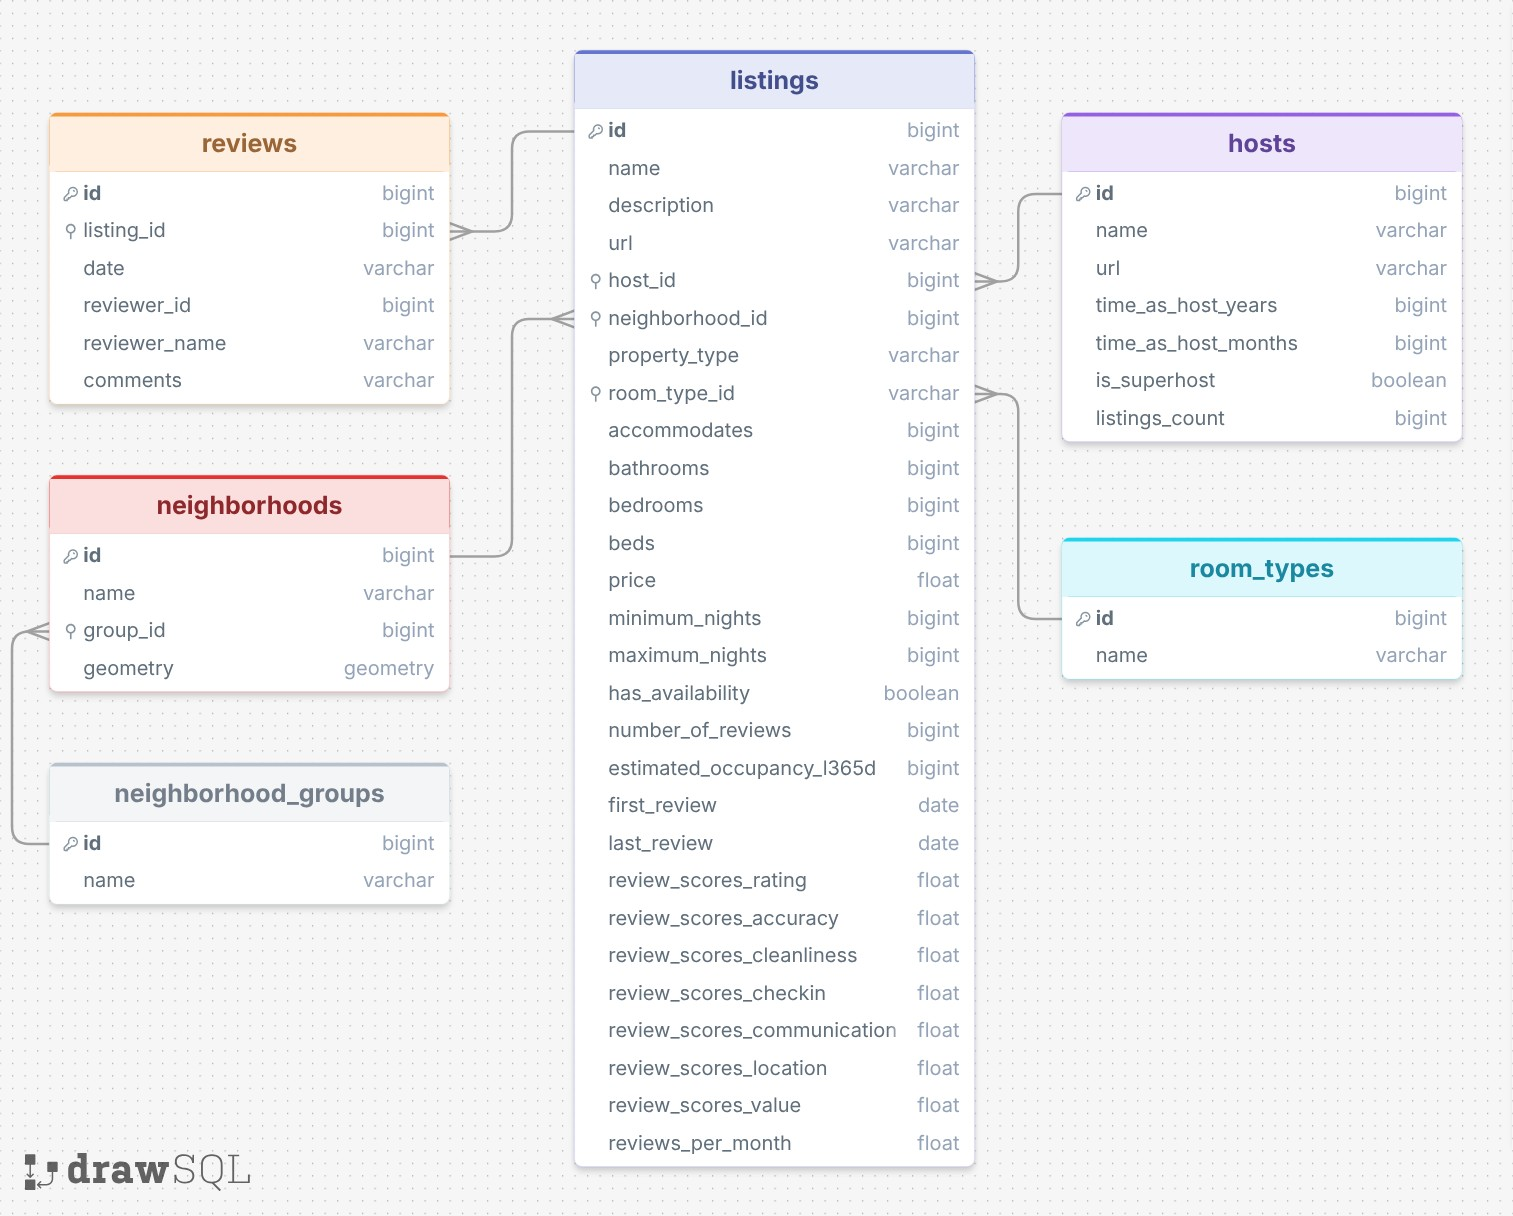

In [175]:
from IPython.display import Image, display

display(Image(filename="../erd.jpg"))

# 3. Building the Tables

Next, we create the tables shown in the diagram above.

In [157]:
neighborhood_groups = pd.DataFrame({'name': ["Central", "South", "North", "West"]}, index=range(1,5))
neighborhood_groups = neighborhood_groups.reset_index()
neighborhood_groups = neighborhood_groups.rename(columns={'index':'id'})
neighborhood_groups

,id,name
0,1,Central
1,2,South
2,3,North
3,4,West


In [158]:
neighborhoods = neighborhoods_raw
neighborhoods = neighborhoods.reset_index()
neighborhoods = neighborhoods.rename(columns={'index':'id','neighbourhood_group':'group_id', 'neighbourhood':'name'})
neighborhoods = neighborhoods[['id','name', 'group_id']]
neighborhoods['geometry'] = neighborhoods_geo_raw['geometry']
neighborhoods

,id,name,group_id,geometry
0,0,Abolição,3,"MULTIPOLYGON Z (((-43.10567 -22.74888 0, -43.1..."
1,1,Acari,3,"MULTIPOLYGON Z (((-43.1717 -22.77661 0, -43.17..."
2,2,Água Santa,3,"MULTIPOLYGON Z (((-43.18915 -22.78318 0, -43.1..."
3,3,Alto da Boa Vista,2,"MULTIPOLYGON Z (((-43.22804 -22.78374 0, -43.2..."
4,4,Anchieta,3,"MULTIPOLYGON Z (((-43.20763 -22.79498 0, -43.2..."
...,...,...,...,...
155,155,Vila Kosmos,3,"MULTIPOLYGON Z (((-43.52203 -23.0078 0, -43.52..."
156,156,Vila Militar,4,"MULTIPOLYGON Z (((-43.50815 -23.0331 0, -43.50..."
157,157,Vila Valqueire,4,"MULTIPOLYGON Z (((-43.22518 -22.87464 0, -43.2..."
158,158,Vista Alegre,3,"MULTIPOLYGON Z (((-43.37902 -22.85022 0, -43.3..."


In [194]:
reviews = reviews_raw
reviews = reviews[['id', 'listing_id', 'date', 'reviewer_id', 'reviewer_name', 'comments']]
reviews


,id,listing_id,date,reviewer_id,reviewer_name,comments
0,64852,17878,2010-07-15,135370,Tia,This apartment is in a perfect location -- two...
1,76744,17878,2010-08-11,10206,Mimi,we had a really great experience staying in Ma...
2,137528,17878,2010-11-12,230449,Orene,In general very good and reasonable price.\r<b...
3,147594,17878,2010-12-01,219338,David,The apt was nice and in a great location only ...
4,152368,17878,2010-12-12,266847,Armi,At Copacabana apartment is best the situation ...
...,...,...,...,...,...,...
1388467,1711040180488331720,1705912356668114238,2026-06-18,686444676,Leandro Marcos,Excelente estadia! O apartamento é exatamente ...
1388468,1711789968070931000,1705980635014402784,2026-06-19,432380912,Bruno,"Lugar top muito bom, só tive uma demora pra co..."
1388469,1715978549692135289,1712609523382975849,2026-06-25,727518181,Maria Ines,"O apartamento é idêntico ao anunciado: limpo, ..."
1388470,1715398827527053126,1712661461624211517,2026-06-24,22550309,Vanessa,"Apartamento impecável, fiel às fotos. A locali..."


In [160]:
room_types = pd.DataFrame({'name': ['Private room', 'Entire home/apt', 'Shared room', 'Hotel room']}, index=range(1,5))
room_types = room_types.reset_index()
room_types = room_types.rename(columns={'index':'id'})
room_types

,id,name
0,1,Private room
1,2,Entire home/apt
2,3,Shared room
3,4,Hotel room


In [161]:
host_columns = ['host_id', 'host_url', 'host_name', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_is_superhost', 'host_listings_count']
hosts = listings_clean[host_columns]
hosts = hosts.rename(columns=lambda column: column.replace("host_", "", 1))
hosts = hosts.rename(columns={'hosts_time_as_years':'time_as_host_years','hosts_time_as_months':'time_as_host_years'})
hosts = hosts[['id', 'name', 'url', 'time_as_host_years', 'time_as_host_years', 'is_superhost', 'listings_count']]
hosts

,id,name,url,time_as_host_years,time_as_host_years,time_as_host_years,time_as_host_years,is_superhost,listings_count
0,546603190,Ananda,https://www.airbnb.com/users/show/546603190,2.0,7.0,2.0,7.0,False,1
1,737983482,Yuri,https://www.airbnb.com/users/show/737983482,0.0,0.0,0.0,0.0,False,1
2,341395950,Mabel,https://www.airbnb.com/users/show/341395950,6.0,3.0,6.0,3.0,False,1
3,173836079,Roberta,https://www.airbnb.com/users/show/173836079,3.0,5.0,3.0,5.0,False,27
4,69238992,Júnior,https://www.airbnb.com/users/show/69238992,3.0,8.0,3.0,8.0,False,3
...,...,...,...,...,...,...,...,...,...
48708,745550239,Cristian,https://www.airbnb.com/users/show/745550239,0.0,4.0,0.0,4.0,True,7
48709,1656964742745518639,Marcos Rimulo,https://www.airbnb.com/users/show/165696474274...,0.0,2.0,0.0,2.0,False,1
48710,120563875,José Raimundo Dos Anjos Souza,https://www.airbnb.com/users/show/120563875,9.0,3.0,9.0,3.0,False,1
48711,235143357,Thiago,https://www.airbnb.com/users/show/235143357,3.0,9.0,3.0,9.0,False,1


In [162]:
hosts = hosts.drop_duplicates(subset='id')
hosts

,id,name,url,time_as_host_years,time_as_host_years,time_as_host_years,time_as_host_years,is_superhost,listings_count
0,546603190,Ananda,https://www.airbnb.com/users/show/546603190,2.0,7.0,2.0,7.0,False,1
1,737983482,Yuri,https://www.airbnb.com/users/show/737983482,0.0,0.0,0.0,0.0,False,1
2,341395950,Mabel,https://www.airbnb.com/users/show/341395950,6.0,3.0,6.0,3.0,False,1
3,173836079,Roberta,https://www.airbnb.com/users/show/173836079,3.0,5.0,3.0,5.0,False,27
4,69238992,Júnior,https://www.airbnb.com/users/show/69238992,3.0,8.0,3.0,8.0,False,3
...,...,...,...,...,...,...,...,...,...
48707,738512297,Ailton,https://www.airbnb.com/users/show/738512297,0.0,5.0,0.0,5.0,False,1
48709,1656964742745518639,Marcos Rimulo,https://www.airbnb.com/users/show/165696474274...,0.0,2.0,0.0,2.0,False,1
48710,120563875,José Raimundo Dos Anjos Souza,https://www.airbnb.com/users/show/120563875,9.0,3.0,9.0,3.0,False,1
48711,235143357,Thiago,https://www.airbnb.com/users/show/235143357,3.0,9.0,3.0,9.0,False,1


In [163]:
host_columns.remove('host_id')
listings = listings_clean.drop(columns=host_columns)
listings

,id,listing_url,name,description,host_id,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,has_availability,number_of_reviews,estimated_occupancy_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,price_outlier,price_imputed
0,1025196153924029661,https://www.airbnb.com/rooms/1025196153924029661,Quartos disponíveis no Recreio,NaN,546603190,Recreio dos Bandeirantes,Private room in rental unit,Private room,2,4 baths,2,2,"[""Kitchen"", ""Air conditioning"", ""Dedicated wor...",52.5,1,1125,False,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True
1,1697400829368754530,https://www.airbnb.com/rooms/1697400829368754530,Casa próxima a Floresta da Tijuca,Take a break to relax in this serene oasis in ...,737983482,Alto da Boa Vista,Private room in home,Private room,2,1 shared bath,1,1,"[""Kitchen"", ""TV"", ""Smoking allowed"", ""Dedicate...",37.0,1,365,True,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
2,42874066,https://www.airbnb.com/rooms/42874066,Alugo uma vaga para sexo feminino Recreio,NaN,341395950,Recreio dos Bandeirantes,Private room in rental unit,Private room,1,1 shared bath,<NA>,1,"[""Kitchen"", ""Air conditioning"", ""Fire extingui...",282.0,30,1125,True,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
3,1543530193994981165,https://www.airbnb.com/rooms/1543530193994981165,Barra Vista maravilhosa,"Kick back and relax in this calm, stylish space.",173836079,Barra da Tijuca,Entire rental unit,Entire home/apt,2,1 bath,1,<NA>,"[""Wifi"", ""Microwave"", ""Pool"", ""Air conditionin...",120.0,3,28,True,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
4,831750365913119274,https://www.airbnb.com/rooms/831750365913119274,Suíte Rio BR,Spacious and pleasant suite in a family home.,69238992,Bento Ribeiro,Private room in home,Private room,1,1 private bath,<NA>,1,"[""Wifi"", ""Dedicated workspace""]",98.0,21,365,True,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48708,1710167672135654837,https://www.airbnb.com/rooms/1710167672135654837,Sua Casa de Luxo no Rio Espera por Você,Luxury house with a sophisticated structure 🏠<...,745550239,Vila Valqueire,Entire home,Entire home/apt,16,5.5 baths,4,4,"[""Kitchen"", ""Outdoor shower"", ""Hot tub"", ""Air ...",212.0,2,365,True,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
48709,1671515558504441333,https://www.airbnb.com/rooms/1671515558504441333,jaunas ville,"Quiet, noise-free location opposite a nature r...",1656964742745518639,Vila Valqueire,Entire home,Entire home/apt,4,4 baths,3,3,"[""Kitchen"", ""Outdoor shower"", ""Air conditionin...",1211.0,1,365,True,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
48710,17696434,https://www.airbnb.com/rooms/17696434,Bella Vista,24hrs tree-lined street The residence is locat...,120563875,Zumbi,Entire home,Entire home/apt,3,1 bath,2,<NA>,"[""Drying rack for clothing"", ""55 inch HDTV wit...",139.5,2,30,True,9,0,2017-08-22,2025-03-03,4.78,4.78,4.89,5.0,4.89,4.78,4.78,0.08,False,True
48711,721042507491251981,https://www.airbnb.com/rooms/721042507491251981,Quarto/Banho Privado,In the room will have:<br />Ventiator;<br />Sm...,235143357,Zumbi,Private room in casa particular,Private room,1,1 private bath,1,1,"[""Kitchen"", ""Air conditioning"", ""Hair dryer"", ...",27.0,2,365,True,1,0,2022-12-11,2022-12-11,5.00,5.00,5.00,5.0,5.00,5.00,5.00,0.02,False,False


In [ ]:
name_to_id = neighborhoods.reset_index().set_index("name")["id"]
mapped_ids = listings["neighbourhood_cleansed"].map(name_to_id)

# Check for names that did not match
listings.loc[mapped_ids.isna(), "neighbourhood_cleansed"].unique()

listings["neighborhood_id"] = mapped_ids
listings = listings.drop(columns="neighbourhood_cleansed")


,id,listing_url,name,description,host_id,property_type,room_type,accommodates,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,has_availability,number_of_reviews,estimated_occupancy_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,price_outlier,price_imputed,neighborhood_id
0,1025196153924029661,https://www.airbnb.com/rooms/1025196153924029661,Quartos disponíveis no Recreio,NaN,546603190,Private room in rental unit,Private room,2,4 baths,2,2,"[""Kitchen"", ""Air conditioning"", ""Dedicated wor...",52.5,1,1125,False,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,118
1,1697400829368754530,https://www.airbnb.com/rooms/1697400829368754530,Casa próxima a Floresta da Tijuca,Take a break to relax in this serene oasis in ...,737983482,Private room in home,Private room,2,1 shared bath,1,1,"[""Kitchen"", ""TV"", ""Smoking allowed"", ""Dedicate...",37.0,1,365,True,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,3
2,42874066,https://www.airbnb.com/rooms/42874066,Alugo uma vaga para sexo feminino Recreio,NaN,341395950,Private room in rental unit,Private room,1,1 shared bath,<NA>,1,"[""Kitchen"", ""Air conditioning"", ""Fire extingui...",282.0,30,1125,True,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,118
3,1543530193994981165,https://www.airbnb.com/rooms/1543530193994981165,Barra Vista maravilhosa,"Kick back and relax in this calm, stylish space.",173836079,Entire rental unit,Entire home/apt,2,1 bath,1,<NA>,"[""Wifi"", ""Microwave"", ""Pool"", ""Air conditionin...",120.0,3,28,True,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,9
4,831750365913119274,https://www.airbnb.com/rooms/831750365913119274,Suíte Rio BR,Spacious and pleasant suite in a family home.,69238992,Private room in home,Private room,1,1 private bath,<NA>,1,"[""Wifi"", ""Dedicated workspace""]",98.0,21,365,True,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48708,1710167672135654837,https://www.airbnb.com/rooms/1710167672135654837,Sua Casa de Luxo no Rio Espera por Você,Luxury house with a sophisticated structure 🏠<...,745550239,Entire home,Entire home/apt,16,5.5 baths,4,4,"[""Kitchen"", ""Outdoor shower"", ""Hot tub"", ""Air ...",212.0,2,365,True,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,157
48709,1671515558504441333,https://www.airbnb.com/rooms/1671515558504441333,jaunas ville,"Quiet, noise-free location opposite a nature r...",1656964742745518639,Entire home,Entire home/apt,4,4 baths,3,3,"[""Kitchen"", ""Outdoor shower"", ""Air conditionin...",1211.0,1,365,True,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,157
48710,17696434,https://www.airbnb.com/rooms/17696434,Bella Vista,24hrs tree-lined street The residence is locat...,120563875,Entire home,Entire home/apt,3,1 bath,2,<NA>,"[""Drying rack for clothing"", ""55 inch HDTV wit...",139.5,2,30,True,9,0,2017-08-22,2025-03-03,4.78,4.78,4.89,5.0,4.89,4.78,4.78,0.08,False,True,159
48711,721042507491251981,https://www.airbnb.com/rooms/721042507491251981,Quarto/Banho Privado,In the room will have:<br />Ventiator;<br />Sm...,235143357,Private room in casa particular,Private room,1,1 private bath,1,1,"[""Kitchen"", ""Air conditioning"", ""Hair dryer"", ...",27.0,2,365,True,1,0,2022-12-11,2022-12-11,5.00,5.00,5.00,5.0,5.00,5.00,5.00,0.02,False,False,159


In [165]:
name_to_id = room_types.reset_index().set_index("name")["id"]
mapped_ids = listings["room_type"].map(name_to_id)

# Check for names that did not match
listings.loc[mapped_ids.isna(), "room_type"].unique()

listings["room_type_id"] = mapped_ids
listings = listings.drop(columns="room_type")
listings

,id,listing_url,name,description,host_id,property_type,accommodates,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,has_availability,number_of_reviews,estimated_occupancy_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,price_outlier,price_imputed,neighborhood_id,room_type_id
0,1025196153924029661,https://www.airbnb.com/rooms/1025196153924029661,Quartos disponíveis no Recreio,NaN,546603190,Private room in rental unit,2,4 baths,2,2,"[""Kitchen"", ""Air conditioning"", ""Dedicated wor...",52.5,1,1125,False,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,118,1
1,1697400829368754530,https://www.airbnb.com/rooms/1697400829368754530,Casa próxima a Floresta da Tijuca,Take a break to relax in this serene oasis in ...,737983482,Private room in home,2,1 shared bath,1,1,"[""Kitchen"", ""TV"", ""Smoking allowed"", ""Dedicate...",37.0,1,365,True,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,3,1
2,42874066,https://www.airbnb.com/rooms/42874066,Alugo uma vaga para sexo feminino Recreio,NaN,341395950,Private room in rental unit,1,1 shared bath,<NA>,1,"[""Kitchen"", ""Air conditioning"", ""Fire extingui...",282.0,30,1125,True,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,118,1
3,1543530193994981165,https://www.airbnb.com/rooms/1543530193994981165,Barra Vista maravilhosa,"Kick back and relax in this calm, stylish space.",173836079,Entire rental unit,2,1 bath,1,<NA>,"[""Wifi"", ""Microwave"", ""Pool"", ""Air conditionin...",120.0,3,28,True,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,9,2
4,831750365913119274,https://www.airbnb.com/rooms/831750365913119274,Suíte Rio BR,Spacious and pleasant suite in a family home.,69238992,Private room in home,1,1 private bath,<NA>,1,"[""Wifi"", ""Dedicated workspace""]",98.0,21,365,True,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,13,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48708,1710167672135654837,https://www.airbnb.com/rooms/1710167672135654837,Sua Casa de Luxo no Rio Espera por Você,Luxury house with a sophisticated structure 🏠<...,745550239,Entire home,16,5.5 baths,4,4,"[""Kitchen"", ""Outdoor shower"", ""Hot tub"", ""Air ...",212.0,2,365,True,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,157,2
48709,1671515558504441333,https://www.airbnb.com/rooms/1671515558504441333,jaunas ville,"Quiet, noise-free location opposite a nature r...",1656964742745518639,Entire home,4,4 baths,3,3,"[""Kitchen"", ""Outdoor shower"", ""Air conditionin...",1211.0,1,365,True,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,157,2
48710,17696434,https://www.airbnb.com/rooms/17696434,Bella Vista,24hrs tree-lined street The residence is locat...,120563875,Entire home,3,1 bath,2,<NA>,"[""Drying rack for clothing"", ""55 inch HDTV wit...",139.5,2,30,True,9,0,2017-08-22,2025-03-03,4.78,4.78,4.89,5.0,4.89,4.78,4.78,0.08,False,True,159,2
48711,721042507491251981,https://www.airbnb.com/rooms/721042507491251981,Quarto/Banho Privado,In the room will have:<br />Ventiator;<br />Sm...,235143357,Private room in casa particular,1,1 private bath,1,1,"[""Kitchen"", ""Air conditioning"", ""Hair dryer"", ...",27.0,2,365,True,1,0,2022-12-11,2022-12-11,5.00,5.00,5.00,5.0,5.00,5.00,5.00,0.02,False,False,159,1


In [166]:
listings = listings.rename(columns={"bathrooms_text":"bathrooms",'listing_url':'url'})

# 4. Checking the Foreign Keys

Before loading the data into tables connected by foreign keys, it's important to verify that every foreign key value in a child table actually has a matching entry in its parent table's index; otherwise, the database would reject the insert, or silently allow an invalid reference if constraints aren't enforced. The `match_keys` function below checks this: it takes a child column (`df1`) and a parent DataFrame (`df2`), and tests whether every unique value in `df1` is present in `df2`'s index. If all values match, it returns `True`. Otherwise, it returns the specific values that are missing, which makes it straightforward to pinpoint the problematic rows for further investigation.

In [181]:
match_keys(listings["neighborhood_id"], neighborhoods)

True

In [182]:
match_keys(neighborhoods["group_id"], neighborhood_groups)

True

In [184]:
match_keys(listings["room_type_id"], room_types)

True

In [185]:
match_keys(listings["host_id"],hosts)

True

In [183]:
match_keys(reviews["listing_id"], listings)

Index([ 699242135357183650,  883476211654884467,  925531549733762400,
        942587218462781381,  961385910390885850,  981058347680558849,
       1032324646372325183, 1035681237265746722, 1079694796572758271,
       1329915338008284589, 1398031955857332449, 1448772847143769985,
       1460358030174298550, 1617654557338436040],
      dtype='int64')

We need to drop the rows in `reviews` for which there is no corresponding listing.

In [199]:
ids_to_drop = match_keys(reviews["listing_id"], listings).tolist()
reviews = reviews.loc[~reviews["listing_id"].isin(ids_to_drop)]

# 5. Creating the Database and Loading It

In [294]:
db_path = Path("../data/clean/airbnb-rio.db")

if "con" in globals():
    con.close()

db_path.unlink(missing_ok=True)

con = sqlite3.connect(db_path)
con.execute("PRAGMA foreign_keys = ON")
con.executescript(Path("../sql/schema.sql").read_text())

In [295]:
neighborhood_groups_db = neighborhood_groups.copy()

neighborhoods_db = neighborhoods.copy()
neighborhoods_db["geometry"] = neighborhoods_db["geometry"].map(
    lambda geometry: geometry.wkt
)

hosts_db = hosts.copy()
listings_db = listings.copy()
reviews_db = reviews.copy()
room_types_db = room_types.copy()

In [296]:
loads = [
    ("neighborhood_groups", neighborhood_groups_db),
    ("neighborhoods", neighborhoods_db),
    ("hosts", hosts_db),
    ("room_types", room_types_db),
    ("listings", listings_db),
    ("reviews", reviews_db),
]

for table, df in loads:
    try:
        df.to_sql(table, con, if_exists="append", index=False)
        print(f"Loaded {table}: {len(df)} rows")
    except Exception as error:
        print(f"Failed loading {table}: {error}")
        print("DataFrame columns:", df.columns.tolist())
        raise

Loaded neighborhood_groups: 4 rows
Loaded neighborhoods: 160 rows
Loaded hosts: 27688 rows
Loaded room_types: 4 rows
Loaded listings: 48713 rows
Loaded reviews: 1387891 rows


# 6. Verifying

In [290]:
cursor = con.cursor()

In [305]:
pd.read_sql("SELECT * FROM listings;", con)

,id,name,description,url,host_id,neighborhood_id,property_type,room_type_id,accommodates,bathrooms,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,has_availability,number_of_reviews,estimated_occupancy_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,price_outlier,price_imputed
0,17878,"Very Nice 2Br in Copacabana w. balcony, fast WiFi",Please note that elevated rates apply for New ...,https://www.airbnb.com/rooms/17878,68997,36,Entire condo,2,5,1 bath,2.0,2.0,"[""Portable fans"", ""Private entrance"", ""Consul ...",96.0,1.0,28.0,1,355,108,2010-07-15,2026-06-09,4.72,4.77,4.65,4.83,4.91,4.78,4.68,1.83,0,0
1,25026,Beautiful Modern Decorated Studio in Copacabana,"**Fully renovated in Dec 2022, new kitchen, n...",https://www.airbnb.com/rooms/25026,102840,36,Entire rental unit,2,3,1 bath,1.0,2.0,"[""Keypad"", ""Single level home"", ""Coffee maker""...",71.0,2.0,60.0,1,327,90,2010-06-07,2026-06-20,4.76,4.75,4.82,4.84,4.93,4.86,4.66,1.67,0,0
2,35764,COPACABANA SEA BREEZE - RIO - 25 X Superhost,Our newly renovated studio is located in the b...,https://www.airbnb.com/rooms/35764,153691,36,Entire loft,2,2,1.5 baths,1.0,1.0,"[""Coffee maker"", ""Stove"", ""Elevator"", ""Hangers...",57.0,3.0,15.0,1,556,240,2010-10-03,2026-06-15,4.91,4.94,4.92,4.97,4.95,4.95,4.89,2.90,0,0
3,48305,Bright 6bed Penthouse Seconds from Beach,Enter Bossa Nova's history by staying in the v...,https://www.airbnb.com/rooms/48305,70933,68,Entire rental unit,2,13,7 baths,6.0,7.0,"[""Private entrance"", ""Coffee maker"", ""Oven"", ""...",535.0,5.0,89.0,1,185,20,2011-03-02,2026-01-21,4.77,4.74,4.73,4.85,4.85,4.95,4.60,0.99,0,0
4,48901,Extra large 4 bedrooms on AtlanticAve. Copacabana,LARGE Beach side 4 bedrooms 2 Complete bathro...,https://www.airbnb.com/rooms/48901,222884,36,Entire rental unit,2,9,2.5 baths,4.0,5.0,"[""Portable fans"", ""Other gas stove"", ""Hot wate...",161.0,2.0,1125.0,1,75,162,2015-08-01,2026-06-21,4.60,4.63,4.45,4.88,4.85,4.96,4.55,0.56,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48708,1714791135195522143,"Hotel nacional, Rio de Janeiro, acomodação de ...",Enjoy a luxurious experience in a spacious and...,https://www.airbnb.com/rooms/1714791135195522143,1671813883647823045,131,Room in hotel,1,6,1 private bath,1.0,2.0,"[""Exercise equipment"", ""Wifi"", ""Pool"", ""Fire e...",124.0,1.0,7.0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
48709,1714834584390200791,Frente a Praia,Two apartments in a building facing Leme/Copac...,https://www.airbnb.com/rooms/1714834584390200791,515537941,83,Entire rental unit,2,4,2 baths,2.0,2.0,"[""Private entrance"", ""Hot water kettle"", ""Gate...",85.0,1.0,365.0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
48710,1714866699267887048,Conforto no coração da cidade (Centro),Enjoy a comfortable stay in a cozy one-bedroom...,https://www.airbnb.com/rooms/1714866699267887048,18288215,28,Entire rental unit,2,4,1 bath,1.0,1.0,"[""Refrigerator"", ""Microwave"", ""Other gas stove...",43.0,2.0,365.0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
48711,1714868751236076121,Studio em Botafogo | Excelente localização 02,"Stay in a modern, charming and fully equipped ...",https://www.airbnb.com/rooms/1714868751236076121,223173237,15,Entire rental unit,2,4,1 bath,1.0,2.0,"[""Bed linens"", ""Hot water"", ""Free street parki...",46.0,2.0,365.0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


In [304]:
pd.read_sql("SELECT * FROM neighborhoods;", con)

,id,name,group_id,geometry
0,0,Abolição,3,"MULTIPOLYGON Z (((-43.105672 -22.748877 0, -43..."
1,1,Acari,3,"MULTIPOLYGON Z (((-43.171698 -22.776612 0, -43..."
2,2,Água Santa,3,"MULTIPOLYGON Z (((-43.189152 -22.78318 0, -43...."
3,3,Alto da Boa Vista,2,"MULTIPOLYGON Z (((-43.228043 -22.783736 0, -43..."
4,4,Anchieta,3,"MULTIPOLYGON Z (((-43.207634 -22.794977 0, -43..."
...,...,...,...,...
155,155,Vila Kosmos,3,"MULTIPOLYGON Z (((-43.52203 -23.0078 0, -43.52..."
156,156,Vila Militar,4,"MULTIPOLYGON Z (((-43.508149 -23.033096 0, -43..."
157,157,Vila Valqueire,4,"MULTIPOLYGON Z (((-43.225182 -22.87464 0, -43...."
158,158,Vista Alegre,3,"MULTIPOLYGON Z (((-43.379023 -22.850219 0, -43..."


In [303]:
pd.read_sql("SELECT * FROM neighborhood_groups;", con)

,id,name
0,1,Central
1,2,South
2,3,North
3,4,West


In [306]:
pd.read_sql("SELECT * FROM hosts;", con)

,id,name,url,time_as_host_years,time_as_host_months,is_superhost,listings_count
0,3607,Ana,https://www.airbnb.com/users/show/3607,12.0,None,1,3.0
1,11739,Eric,https://www.airbnb.com/users/show/11739,10.0,None,0,7.0
2,19065,Morena,https://www.airbnb.com/users/show/19065,13.0,None,0,5.0
3,34105,Giselle,https://www.airbnb.com/users/show/34105,12.0,None,1,2.0
4,38907,Tropical Vibes,https://www.airbnb.com/users/show/38907,10.0,None,1,4.0
...,...,...,...,...,...,...,...
27683,1712365522191390712,Yara,https://www.airbnb.com/users/show/171236552219...,0.0,None,0,1.0
27684,1712383052754531302,Daniele,https://www.airbnb.com/users/show/171238305275...,0.0,None,0,1.0
27685,1712476339062830429,Celso,https://www.airbnb.com/users/show/171247633906...,0.0,None,0,1.0
27686,1713848996533966030,Juliana Dulce Soares,https://www.airbnb.com/users/show/171384899653...,0.0,None,0,1.0


In [307]:
pd.read_sql("SELECT * FROM reviews;", con)

,id,listing_id,date,reviewer_id,reviewer_name,comments
0,50636,25026,2010-06-07,98888,Eduardo,"Me and my girlfriend spent 8 days in rio, we l..."
1,64852,17878,2010-07-15,135370,Tia,This apartment is in a perfect location -- two...
2,76744,17878,2010-08-11,10206,Mimi,we had a really great experience staying in Ma...
3,85230,25026,2010-08-26,206472,Anthony,I heard of AirBnB from a Bloomberg article ht...
4,87207,25026,2010-08-30,187977,Nate,"The apartment was lovely, clean, and well loca..."
...,...,...,...,...,...,...
1387886,1718292180771684665,1600351338821072579,2026-06-28,574504884,Mark,Fantastic apartment with an incredible view. T...
1387887,1718309558373038648,1531619394857696460,2026-06-28,420308145,Rodrigo,"O apartamento é bom, reformado recentemente, e..."
1387888,1719567546011111104,1192912450003434028,2026-06-30,742111051,Elane,"o apartamento do Lucas, foi o melhor apartamen..."
1387889,1719616545270899046,1577037530878186454,2026-06-30,738639566,Zidan,Excelente pousada! Ótima localização em frente...


In [308]:
pd.read_sql("SELECT * FROM room_types;", con)

,id,name
0,1,Private room
1,2,Entire home/apt
2,3,Shared room
3,4,Hotel room


In [310]:
query = """
SELECT
    n.name        AS neighborhood,
    ng.name       AS zone,
    COUNT(l.id)   AS total_listings
FROM neighborhoods AS n
JOIN neighborhood_groups AS ng 
	ON ng.id = n.group_id
LEFT JOIN listings AS l   
	ON l.neighborhood_id = n.id
GROUP BY n.id
ORDER BY total_listings DESC;
"""
pd.read_sql(query, con)

,neighborhood,zone,total_listings
0,Copacabana,South,15036
1,Ipanema,South,3928
2,Barra da Tijuca,West,3759
3,Centro,Central,3295
4,Recreio dos Bandeirantes,West,2477
...,...,...,...
155,Costa Barros,North,0
156,Deodoro,West,0
157,Jacarezinho,North,0
158,Manguinhos,North,0


In [ ]:
con.commit()
cursor.close()
con.close()
print("Connection closed.")

closed
